# Домашняя работа № 10
## «Памперсы или пиво?» — рекомендательная система для Amazon Software

**Задача:** по истории взаимодействий пользователя рекомендовать 10 ещё не встречавшихся ему товаров.
Сравниваются три модели: **MostPopular**, **ItemKNN** и **EASE**.


## 1. Источник данных и постановка задачи

Используется лежащий в проекте **Software_5.json**, категория **Software, 5-core** из
[Amazon Review Data (2018), раздел Small subsets for experimentation](https://cseweb.ucsd.edu/~jmcauley/datasets/amazon_v2/).
На странице источника для этой выборки указано **12 805 отзывов**.
[Прямая ссылка на архив](https://mcauleylab.ucsd.edu/public_datasets/data/amazon_v2/categoryFilesSmall/Software_5.json.gz)
приведена для происхождения данных; локальный файл — распакованный JSON Lines.

5-core означает отбор по числу отзывов пользователя и товара в исходных данных.
После удаления повторных пар минимум пять **различных** товаров/пользователей не гарантируется,
поэтому реальные количества проверяются ниже.

**Выбор целевой переменной.** Решается задача предсказания следующего взаимодействия, а не оценки
в звёздах: наличие отзыва любого рейтинга становится бинарным событием $X_{ui}=1$.
Низкий рейтинг тоже означает взаимодействие, но не обязательно симпатию.
«Релевантный товар» в основных метриках — единственный отложенный товар, независимо от его рейтинга.
Поэтому высокое качество в этой задаче нельзя интерпретировать как удовлетворённость покупкой.
В разделе 9 дополнительно показано качество на пользователях с тестовым рейтингом не ниже 4.

Неизвестные пары — кандидаты с неизвестной релевантностью, а не доказанные отрицательные примеры.

In [1]:
from pathlib import Path
from time import perf_counter
import hashlib
import json
import platform
import importlib.metadata as metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.linalg import cho_factor, cho_solve
from threadpoolctl import threadpool_limits
from IPython.display import display, Markdown

SEED = 42
K = 10
# Ограничение потоков уменьшает накладные расходы на небольших матрицах.
blas_thread_limit = threadpool_limits(limits=1)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (11, 4), 'figure.dpi': 110,
    'font.family': 'DejaVu Sans', 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.titlesize': 12,
})
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', lambda value: f'{value:.4f}')

DATA_PATH = Path('Software_5.json')
if not DATA_PATH.is_file():
    raise FileNotFoundError(
        'Поместите Software_5.json рядом с ноутбуком и запустите Jupyter из этой папки.'
    )

packages = ['numpy', 'pandas', 'scipy', 'matplotlib', 'threadpoolctl',
            'nbformat', 'nbclient', 'ipykernel']
versions = pd.Series({name: metadata.version(name) for name in packages}, name='Версия')
print('Python:', platform.python_version())
print('SHA-256 исходного файла:', hashlib.sha256(DATA_PATH.read_bytes()).hexdigest())
display(versions.to_frame())

Python: 3.13.5
SHA-256 исходного файла: bbdeb56708e8e9ce7f793c3036f60eba7f51c8156e5e968c61e4ca99331340b5


,Версия
numpy,2.1.3
pandas,2.2.3
scipy,1.15.3
matplotlib,3.10.0
threadpoolctl,3.5.0
nbformat,5.10.4
nbclient,0.10.2
ipykernel,6.29.5


## 2. Загрузка и проверка качества

Читаются только идентификаторы, рейтинг и время. `row_id` сохраняет порядок строк исходного файла
и служит воспроизводимым дополнительным ключом для отзывов с одинаковым временем.

| Поле источника | Поле в ноутбуке | Назначение |
|---|---|---|
| `reviewerID` | `user_id` | Идентификатор пользователя |
| `asin` | `item_id` | Идентификатор товара Amazon |
| `overall` | `rating` | Рейтинг 1–5 |
| `unixReviewTime` | `timestamp` | Время отзыва; календарная дата не задаёт порядок внутри дня |

In [2]:
source_fields = ['reviewerID', 'asin', 'overall', 'unixReviewTime']
records = []
with DATA_PATH.open('r', encoding='utf-8') as stream:
    for line_number, line in enumerate(stream):
        if line.strip():
            record = json.loads(line)
            records.append({**{key: record.get(key) for key in source_fields},
                            'row_id': line_number})

raw = pd.DataFrame.from_records(records).rename(columns={
    'reviewerID': 'user_id', 'asin': 'item_id',
    'overall': 'rating', 'unixReviewTime': 'timestamp',
})
del records
required = ['user_id', 'item_id', 'rating', 'timestamp']
display(raw.head())
display(pd.DataFrame({'dtype': raw[required].dtypes.astype(str),
                      'missing': raw[required].isna().sum()}))

clean = raw.dropna(subset=required).copy()
clean['rating'] = pd.to_numeric(clean['rating'], errors='coerce')
clean['timestamp'] = pd.to_numeric(clean['timestamp'], errors='coerce')
valid = (clean['rating'].isin([1, 2, 3, 4, 5])
         & clean['timestamp'].notna() & np.isfinite(clean['timestamp'])
         & clean['timestamp'].ge(0)
         & clean['timestamp'].mod(1).eq(0)
         & clean['user_id'].astype(str).str.strip().ne('')
         & clean['item_id'].astype(str).str.strip().ne(''))
clean = clean.loc[valid].copy()
clean['timestamp'] = clean['timestamp'].astype('int64')
clean['user_id'] = clean['user_id'].astype(str)
clean['item_id'] = clean['item_id'].astype(str)
clean['date'] = pd.to_datetime(clean['timestamp'], unit='s', utc=True, errors='coerce')
clean = clean.dropna(subset=['date'])

# Для рекомендации нового товара повторные отзывы об одной паре не нужны.
# Берём ПЕРВОЕ событие, не подменяя его более поздним рейтингом или временем.
events = (clean.sort_values(['user_id', 'timestamp', 'row_id'], kind='stable')
          .drop_duplicates(['user_id', 'item_id'], keep='first').copy())

quality = pd.Series({
    'Исходных отзывов': len(raw),
    'Некорректных/неполных строк удалено': len(raw) - len(clean),
    'Повторных строк по 4 полям': int(clean.duplicated(required).sum()),
    'Повторных пар user-item удалено': len(clean) - len(events),
    'Уникальных пар после очистки': len(events),
}, name='Количество')
display(quality.to_frame())
assert not events.duplicated(['user_id', 'item_id']).any()
assert events[required].notna().all().all()

,user_id,item_id,rating,timestamp,row_id
0,A38NELQT98S4H8,0321719816,4.0000,1287532800,0
1,A3QJU4FEN8PQSZ,0321719816,4.0000,1287360000,1
2,ACJT8MUC0LRF0,0321719816,5.0000,1287187200,2
3,AYUF7YETYOLNX,0321719816,5.0000,1286841600,3
4,A31ICLWQ9CSHRS,0321719816,5.0000,1286409600,4


,dtype,missing
user_id,object,0
item_id,object,0
rating,float64,0
timestamp,int64,0


,Количество
Исходных отзывов,12805
Некорректных/неполных строк удалено,0
Повторных строк по 4 полям,845
Повторных пар user-item удалено,921
Уникальных пар после очистки,11884


## 3. Базовый EDA

Сначала анализируются все корректные отзывы и очищенные уникальные взаимодействия.
EDA описывает весь набор, но популярности, похожести, словари и параметры моделей далее
вычисляются только по соответствующей обучающей части.

In [3]:
def describe_interactions(frame):
    n_users, n_items = frame['user_id'].nunique(), frame['item_id'].nunique()
    n_pairs = frame[['user_id', 'item_id']].drop_duplicates().shape[0]
    density = n_pairs / (n_users * n_items)
    return pd.Series({
        'Строк': len(frame), 'Уникальных пользователей': n_users,
        'Уникальных товаров': n_items, 'Уникальных пар': n_pairs,
        'Плотность матрицы': density, 'Разреженность матрицы': 1 - density,
        'Средний рейтинг': frame['rating'].mean(),
        'Доля рейтингов 4–5': frame['rating'].ge(4).mean(),
    })

eda_summary = pd.concat({
    'Все корректные отзывы': describe_interactions(clean),
    'Уникальные взаимодействия': describe_interactions(events),
}, axis=1)
display(eda_summary)
print('Период:', events['date'].min().date(), '—', events['date'].max().date())

user_counts = events.groupby('user_id').size()
item_counts = events.groupby('item_id').size()
display(pd.concat({
    'Товаров у пользователя': user_counts.describe(percentiles=[.25, .5, .75, .95, .99]),
    'Пользователей у товара': item_counts.describe(percentiles=[.25, .5, .75, .95, .99]),
}, axis=1))

,Все корректные отзывы,Уникальные взаимодействия
Строк,12805.0000,11884.0000
Уникальных пользователей,1826.0000,1826.0000
Уникальных товаров,802.0000,802.0000
Уникальных пар,11884.0000,11884.0000
Плотность матрицы,0.0081,0.0081
Разреженность матрицы,0.9919,0.9919
Средний рейтинг,3.8779,3.8777
Доля рейтингов 4–5,0.7019,0.7035


Период: 2000-06-26 — 2018-08-26


,Товаров у пользователя,Пользователей у товара
count,1826.0000,802.0000
mean,6.5082,14.8180
std,3.5020,18.5709
min,1.0000,1.0000
25%,5.0000,6.0000
50%,5.0000,11.0000
75%,7.0000,18.0000
95%,13.0000,34.9500
99%,21.0000,64.0000
max,52.0000,227.0000


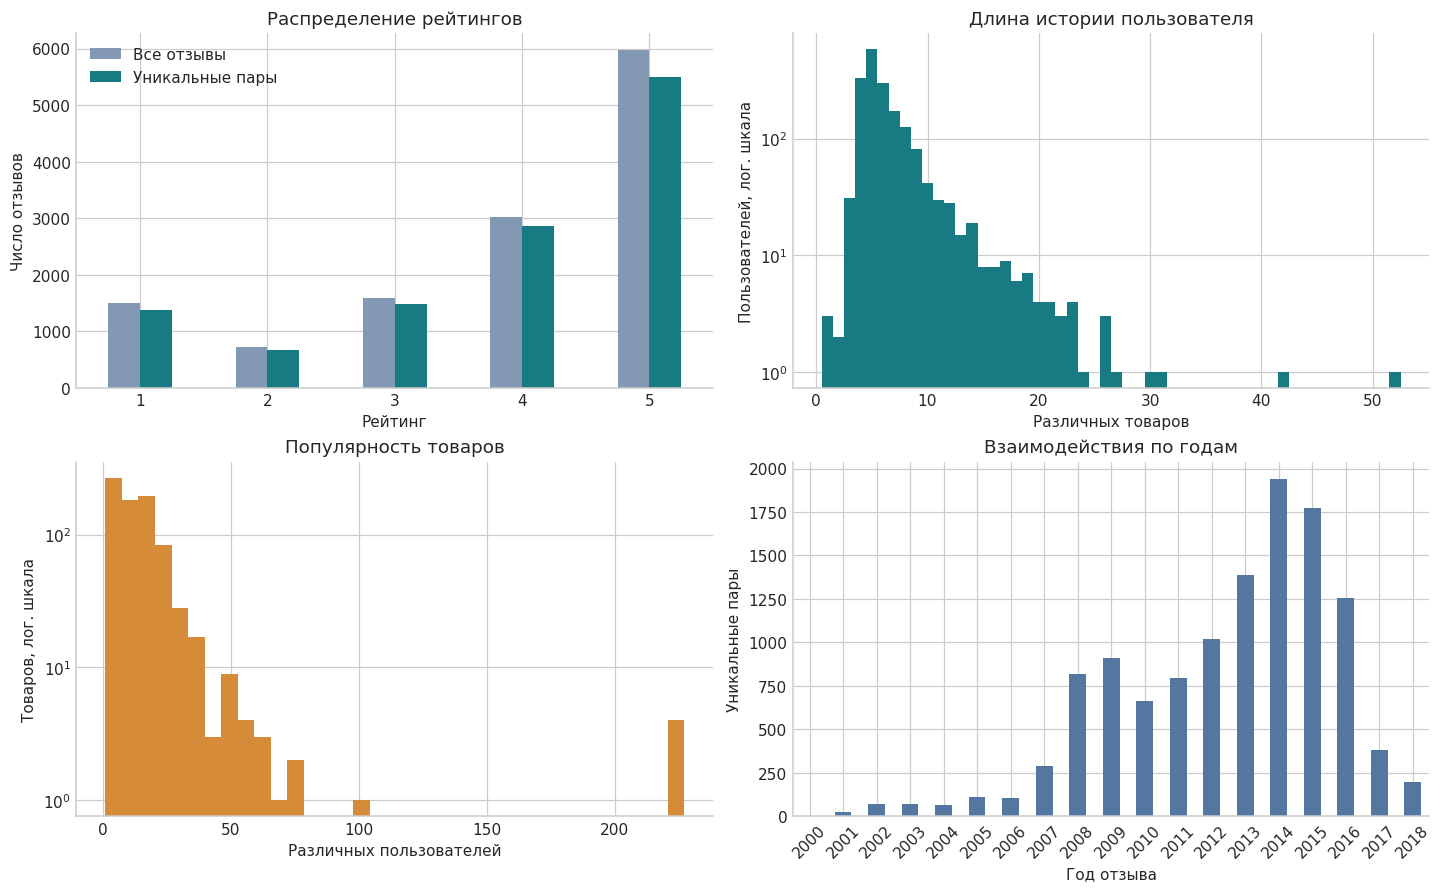

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
rating_counts = pd.DataFrame({
    'Все отзывы': clean['rating'].value_counts().reindex(range(1, 6), fill_value=0),
    'Уникальные пары': events['rating'].value_counts().reindex(range(1, 6), fill_value=0),
})
rating_counts.plot.bar(ax=axes[0, 0], color=['#8298b3', '#187b83'], rot=0)
axes[0, 0].set(title='Распределение рейтингов', xlabel='Рейтинг', ylabel='Число отзывов')
axes[0, 1].hist(user_counts, bins=np.arange(0.5, user_counts.max() + 1.5), color='#187b83')
axes[0, 1].set(title='Длина истории пользователя', xlabel='Различных товаров',
               ylabel='Пользователей, лог. шкала', yscale='log')
axes[1, 0].hist(item_counts, bins=35, color='#d58b37')
axes[1, 0].set(title='Популярность товаров', xlabel='Различных пользователей',
               ylabel='Товаров, лог. шкала', yscale='log')
events.groupby(events['date'].dt.year).size().plot.bar(ax=axes[1, 1], color='#5477a2', rot=45)
axes[1, 1].set(title='Взаимодействия по годам', xlabel='Год отзыва', ylabel='Уникальные пары')
plt.show()

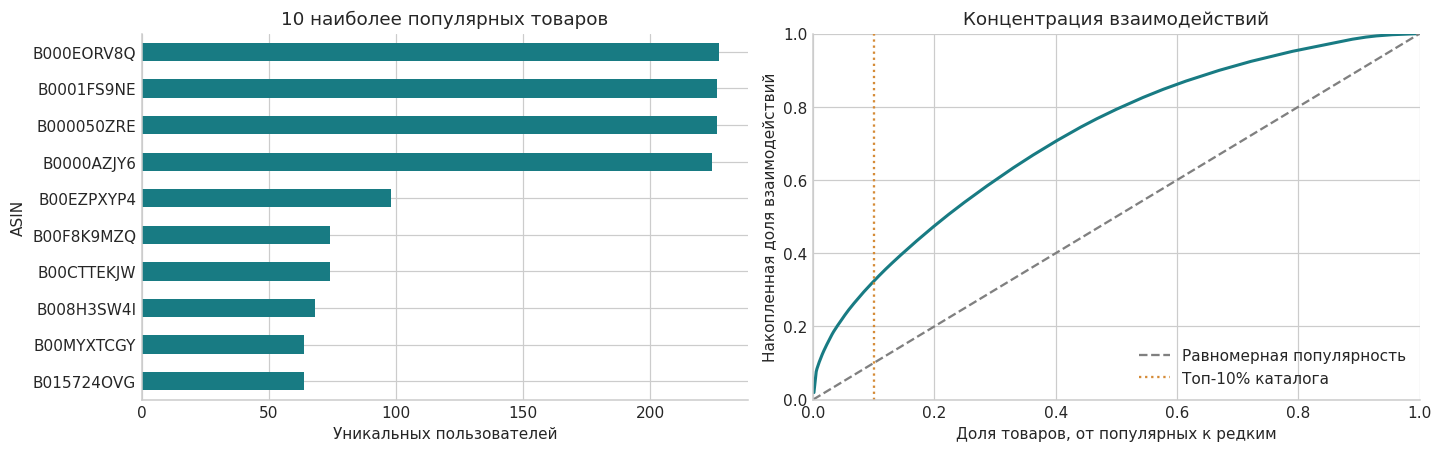


**Выводы EDA.** После удаления повторов осталось **11,884** взаимодействия,
**1,826** пользователей и **802** товара.
Разреженность равна **99.19%**.
Медиана длины истории — **5** товаров;
это делает leave-one-out практичным, но ограничивает объём информации о пользователе.

Среди исходных корректных отзывов **70.19%** имеют 4–5 звёзд.
Рейтинги смещены к положительным оценкам; предсказание среднего рейтинга не решает задачу top-10.
На 10 самых популярных товаров приходится **11.32%** уникальных взаимодействий,
а на наиболее популярные 10% каталога — **32.54%**.
Поэтому популярность — содержательный baseline; персонализированные модели должны проверяться
и на точность, и на охват каталога. Названия товаров не загружаются: на графике показаны ASIN.


In [5]:
top_items = item_counts.sort_values(ascending=False, kind='stable')
top_10_share = top_items.head(10).sum() / len(events)
head_size = max(1, int(np.ceil(0.1 * len(top_items))))
head_share = top_items.head(head_size).sum() / len(events)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
top_items.head(10).sort_values().plot.barh(ax=axes[0], color='#187b83')
axes[0].set(title='10 наиболее популярных товаров', xlabel='Уникальных пользователей', ylabel='ASIN')
x = np.arange(1, len(top_items) + 1) / len(top_items)
axes[1].plot(x, top_items.cumsum() / len(events), color='#187b83', linewidth=2)
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Равномерная популярность')
axes[1].axvline(head_size / len(top_items), color='#d58b37', linestyle=':', label='Топ-10% каталога')
axes[1].set(title='Концентрация взаимодействий', xlabel='Доля товаров, от популярных к редким',
            ylabel='Накопленная доля взаимодействий', xlim=(0, 1), ylim=(0, 1))
axes[1].legend()
plt.show()

display(Markdown(f'''
**Выводы EDA.** После удаления повторов осталось **{len(events):,}** взаимодействия,
**{events.user_id.nunique():,}** пользователей и **{events.item_id.nunique():,}** товара.
Разреженность равна **{1 - len(events)/(events.user_id.nunique()*events.item_id.nunique()):.2%}**.
Медиана длины истории — **{user_counts.median():.0f}** товаров;
это делает leave-one-out практичным, но ограничивает объём информации о пользователе.

Среди исходных корректных отзывов **{clean.rating.ge(4).mean():.2%}** имеют 4–5 звёзд.
Рейтинги смещены к положительным оценкам; предсказание среднего рейтинга не решает задачу top-10.
На 10 самых популярных товаров приходится **{top_10_share:.2%}** уникальных взаимодействий,
а на наиболее популярные 10% каталога — **{head_share:.2%}**.
Поэтому популярность — содержательный baseline; персонализированные модели должны проверяться
и на точность, и на охват каталога. Названия товаров не загружаются: на графике показаны ASIN.
'''))

## 4. Разбиение leave-one-out

Для каждого пользователя события упорядочиваются по `(timestamp, row_id)`:

```text
более ранние события          предпоследнее       последнее
└──────── fit ─────────┘      validation           test
└──────────────── train ──────────────┘            test
```

- **Внешнее разбиение:** ровно одно последнее взаимодействие каждого пользователя в `test`, остальные в `train`.
- **Внутреннее разбиение:** из `train` также откладывается последнее событие в `validation`;
  `fit` нужен только для настройки гиперпараметров.
- Нужны хотя бы три различных товара на пользователя, чтобы все три части были непустыми.
  Пользователи с более короткой историей исключаются; их количество и число удалённых строк показаны ниже.
- После выбора параметров модели обучаются заново на всём `train`, включающем validation.
  `test` не используется для выбора параметров или изменения постановки.
- Словарь товаров строится только по обучающей части. Если тестовый товар в ней отсутствует,
  он не может быть рекомендован и получает **нулевые** HR/MRR/NDCG, но пользователь остаётся в оценке.

**Ограничение времени.** Временная метка здесь имеет точность до дня. При совпадении дат порядок
`row_id` воспроизводим, но не доказывает реальную последовательность событий внутри дня.
Кроме того, пользовательский leave-one-out не является единым глобальным временным срезом:
в обучении могут быть события других пользователей позднее тестового события данного пользователя.
Для имитации запуска системы в конкретную дату нужен отдельный глобальный temporal split.

In [6]:
eligible_users = user_counts[user_counts >= 3].index
data = events.loc[events.user_id.isin(eligible_users)].copy()
excluded_users = user_counts.index.difference(eligible_users)

def leave_one_out(frame):
    ordered = frame.sort_values(['user_id', 'timestamp', 'row_id'], kind='stable')
    holdout = ordered.groupby('user_id', sort=False).tail(1).copy()
    history = ordered.drop(index=holdout.index).copy()
    return history, holdout

train, test = leave_one_out(data)
fit, validation = leave_one_out(train)

def assert_split(history, holdout):
    assert holdout.user_id.is_unique
    assert set(history.user_id) == set(holdout.user_id)
    assert set(history.index).isdisjoint(holdout.index)
    left = pd.MultiIndex.from_frame(history[['user_id', 'item_id']])
    right = pd.MultiIndex.from_frame(holdout[['user_id', 'item_id']])
    assert left.intersection(right).empty
    last = history.groupby('user_id').tail(1).set_index('user_id')
    target = holdout.set_index('user_id').loc[last.index]
    assert ((last.timestamp < target.timestamp)
            | ((last.timestamp == target.timestamp) & (last.row_id < target.row_id))).all()

assert_split(train, test)
assert_split(fit, validation)
assert len(train) + len(test) == len(data)
assert len(fit) + len(validation) == len(train)
assert len(validation) == len(test) == data.user_id.nunique()

split_table = pd.DataFrame({
    name: {'Взаимодействий': len(frame), 'Пользователей': frame.user_id.nunique(),
           'Товаров': frame.item_id.nunique(),
           'Мин. история': frame.groupby('user_id').size().min()}
    for name, frame in [('fit', fit), ('validation', validation), ('train = fit + validation', train), ('test', test)]
}).T
print(f'Исключено пользователей с <3 товарами: {len(excluded_users)}; строк: {len(events) - len(data)}.')
display(split_table)

split_diagnostics = []
for name, history, holdout in [('validation', fit, validation), ('test', train, test)]:
    last_time = history.groupby('user_id').timestamp.max()
    target_time = holdout.set_index('user_id').timestamp.reindex(last_time.index)
    cold = ~holdout.item_id.isin(history.item_id)
    split_diagnostics.append({
        'Выборка': name, 'Новых товаров в целях': holdout.loc[cold, 'item_id'].nunique(),
        'Пользователей с новым товаром': int(cold.sum()), 'Доля cold-start': cold.mean(),
        'Цель в тот же день, что конец истории': int(last_time.eq(target_time).sum()),
    })
display(pd.DataFrame(split_diagnostics).set_index('Выборка'))
print('Проверки размеров, порядка событий и отсутствия пересечений пройдены.')

Исключено пользователей с <3 товарами: 5; строк: 7.


,Взаимодействий,Пользователей,Товаров,Мин. история
fit,8235,1821,782,1
validation,1821,1821,544,1
train = fit + validation,10056,1821,796,2
test,1821,1821,480,1


,Новых товаров в целях,Пользователей с новым товаром,Доля cold-start,"Цель в тот же день, что конец истории"
Выборка,,,,
validation,14,29,0.0159,555
test,4,28,0.0154,490


Проверки размеров, порядка событий и отсутствия пересечений пройдены.


## 5. Метрики и единый протокол рекомендаций

У пользователя $u$ один отложенный товар. Пусть $r_u$ — его позиция в top-10,
а при отсутствии в списке $r_u=\infty$. При $N$ пользователях:

$$HR@10=\frac{1}{N}\sum_u\mathbf{1}[r_u\leq10],$$
$$MRR@10=\frac{1}{N}\sum_u\frac{\mathbf{1}[r_u\leq10]}{r_u},$$
$$NDCG@10=\frac{1}{N}\sum_u\frac{\mathbf{1}[r_u\leq10]}{\log_2(r_u+1)}.$$

В коде вклад промаха сразу равен нулю. При одном релевантном товаре $IDCG@10=1$.
HR отвечает на вопрос «попали ли в десятку», MRR сильнее вознаграждает первые места,
NDCG использует более мягкое логарифмическое уменьшение ценности позиции.

$$coverage@10=\frac{\left|\bigcup_u Rec_{10}(u)\right|}{|I_{train}|}.$$

Это **охват каталога**, не доля пользователей. Знаменатель — число товаров соответствующего
обучающего каталога; при validation используется $I_{fit}$. Для test он одинаков для всех моделей.
Дополнительно приводится охват относительно полного каталога моделируемой выборки, включая cold-start.

**Общие правила оценки:**

1. Ранжируются **все** товары обучающего каталога, кроме уже встречавшихся этому пользователю;
   случайная подвыборка отрицательных кандидатов не используется.
2. В каждом списке ровно 10 различных товаров; уже известные товары маскируются до ранжирования.
3. Равные оценки разрешаются по популярности в обучении, затем по ASIN по возрастанию.
   У ItemKNN это также заполняет свободные места популярными товарами при нулевых сходствах.
4. HR, MRR и NDCG усредняются по **всем** тестовым пользователям, в том числе с cold-start целью.
5. Основной критерий выбора параметров и семейства модели — **validation NDCG@10**.

In [7]:
def make_context(history):
    # Словари создаются исключительно из обучающих взаимодействий.
    users = np.array(sorted(history.user_id.unique()))
    items = np.array(sorted(history.item_id.unique()))
    user_to_idx = {user: idx for idx, user in enumerate(users)}
    item_to_idx = {item: idx for idx, item in enumerate(items)}
    rows = history.user_id.map(user_to_idx).to_numpy()
    cols = history.item_id.map(item_to_idx).to_numpy()
    X = sparse.csr_matrix((np.ones(len(history), dtype=np.float64), (rows, cols)),
                          shape=(len(users), len(items)))
    X.sum_duplicates()
    X.data[:] = 1.0
    assert X.nnz == len(history)
    assert X.shape[1] - np.diff(X.indptr).max() >= K
    return {'X': X, 'users': users, 'items': items,
            'user_to_idx': user_to_idx, 'item_to_idx': item_to_idx,
            'popularity': np.asarray(X.sum(axis=0)).ravel()}

def rank_all_items(scores, context, k=K):
    X = context['X']
    scores = np.asarray(scores, dtype=np.float64).copy()
    assert scores.shape == X.shape
    assert np.isfinite(scores).all()
    seen_rows, seen_cols = X.nonzero()
    scores[seen_rows, seen_cols] = -np.inf
    item_indices = np.arange(X.shape[1])  # ASIN уже отсортированы.
    recs = np.empty((X.shape[0], k), dtype=np.int64)
    for user_idx in range(X.shape[0]):
        order = np.lexsort((item_indices, -context['popularity'], -scores[user_idx]))
        recs[user_idx] = order[:k]
        assert np.isfinite(scores[user_idx, recs[user_idx]]).all()
    assert np.all(np.diff(np.sort(recs, axis=1), axis=1) > 0)
    users_repeated = np.repeat(np.arange(X.shape[0]), k)
    assert np.asarray(X[users_repeated, recs.ravel()]).ravel().sum() == 0
    return recs

def metric_contributions(recommendations, targets):
    targets = np.asarray(targets)
    matches = recommendations == targets[:, None]
    hit = matches.any(axis=1)
    rank = np.where(hit, matches.argmax(axis=1) + 1, 0)
    reciprocal = np.divide(1.0, rank, out=np.zeros(len(rank)), where=hit)
    ndcg = np.zeros(len(rank), dtype=float)
    ndcg[hit] = 1.0 / np.log2(rank[hit] + 1)
    return pd.DataFrame({'rank': rank, 'HR@10': hit.astype(float),
                         'MRR@10': reciprocal, 'NDCG@10': ndcg})

def evaluate(recommendations, context, holdout):
    assert holdout.user_id.is_unique
    assert set(holdout.user_id) == set(context['users'])
    targets = holdout.set_index('user_id').loc[context['users']]
    target_indices = targets.item_id.map(context['item_to_idx']).fillna(-1).astype(int).to_numpy()
    per_user = metric_contributions(recommendations, target_indices)
    per_user.index = pd.Index(context['users'], name='user_id')
    per_user['warm_target'] = target_indices >= 0
    per_user['target_item'] = targets.item_id.to_numpy()
    per_user['target_rating'] = targets.rating.to_numpy()
    per_user['history_length'] = np.diff(context['X'].indptr)
    metrics = per_user[['HR@10', 'MRR@10', 'NDCG@10']].mean().to_dict()
    metrics['coverage@10'] = np.unique(recommendations).size / len(context['items'])
    metrics['Рекомендовано товаров'] = np.unique(recommendations).size
    metrics['Пользователей'] = len(per_user)
    assert 0 <= metrics['MRR@10'] <= metrics['NDCG@10'] <= metrics['HR@10'] <= 1
    assert 0 < metrics['coverage@10'] <= 1
    assert per_user.loc[~per_user.warm_target, 'HR@10'].sum() == 0
    return metrics, per_user

fit_context = make_context(fit)
train_context = make_context(train)
display(pd.DataFrame([
    {'Матрица': name, 'Пользователей': ctx['X'].shape[0], 'Товаров': ctx['X'].shape[1],
     'Ненулевых элементов': ctx['X'].nnz,
     'Мин. кандидатов': int(ctx['X'].shape[1] - np.diff(ctx['X'].indptr).max()),
     'Медиана кандидатов': float(np.median(ctx['X'].shape[1] - np.diff(ctx['X'].indptr)))}
    for name, ctx in [('fit', fit_context), ('train', train_context)]
]))

,Матрица,Пользователей,Товаров,Ненулевых элементов,Мин. кандидатов,Медиана кандидатов
0,fit,1821,782,8235,732,779.0000
1,train,1821,796,10056,745,792.0000


### Проверка реализации метрик

В примере ниже цель попадает на позиции 1, 3 и 10; четвёртая цель находится за top-10,
пятая отсутствует в обучающем каталоге. Ожидаемые значения рассчитаны напрямую.
Дополнительная проверка гарантирует, что модель с высокими оценками известных товаров
всё равно не рекомендует их, а равные оценки разрешаются воспроизводимо.

In [8]:
toy_recs = np.tile(np.arange(10), (5, 1))
toy_result = metric_contributions(toy_recs, np.array([0, 2, 9, 10, -1]))
np.testing.assert_allclose(toy_result['HR@10'].mean(), 3 / 5)
np.testing.assert_allclose(toy_result['MRR@10'].mean(), (1 + 1/3 + 1/10) / 5)
np.testing.assert_allclose(toy_result['NDCG@10'].mean(), (1 + 1/np.log2(4) + 1/np.log2(11)) / 5)
assert toy_result['rank'].tolist() == [1, 3, 10, 0, 0]
toy_holdout = pd.DataFrame({'user_id': list('abcde'), 'item_id': [0, 2, 9, 10, -1],
                             'rating': [5, 5, 5, 5, 5]})
toy_evaluation_context = {
    'users': np.array(list('abcde')), 'items': np.arange(12),
    'item_to_idx': {i: i for i in range(12)}, 'X': sparse.csr_matrix((5, 12)),
}
toy_metrics, _ = evaluate(toy_recs, toy_evaluation_context, toy_holdout)
np.testing.assert_allclose(toy_metrics['coverage@10'], 10 / 12)
np.testing.assert_allclose(toy_metrics['HR@10'], 3 / 5)

toy_X = sparse.csr_matrix(([1.0, 1.0], ([0, 1], [0, 1])), shape=(2, 4))
toy_context = {'X': toy_X, 'popularity': np.array([1., 1., 0., 0.])}
toy_scores = np.array([[999., 0., 0., 0.], [0., 999., 0., 0.]])
np.testing.assert_array_equal(rank_all_items(toy_scores, toy_context, k=2), [[1, 2], [0, 2]])
print('Проверки рангов 1/3/10, промахов, cold-start, маскирования и равных оценок пройдены.')

Проверки рангов 1/3/10, промахов, cold-start, маскирования и равных оценок пройдены.


## 6. Три рекомендательные модели

### 6.1. MostPopular — базовая модель

Оценка товара — число различных пользователей, взаимодействовавших с ним в обучении:
$s_{ui}=\sum_v X_{vi}$. Порядок общий, но просмотренные товары удаляются индивидуально.
Baseline не использует персональные вкусы и позволяет проверить, оправдано ли усложнение модели.

### 6.2. ItemKNN — коллаборативная фильтрация по похожести товаров

Вычисляется косинусная похожесть бинарных столбцов матрицы:

$$c_{ij}=\frac{X_{:i}^T X_{:j}}{\sqrt{n_i n_j}}, \qquad n_i=\sum_u X_{ui}.$$

Похожесть дополнительно умножается на $g_{ij}/(g_{ij}+\alpha)$, где
$g_{ij}=X_{:i}^T X_{:j}$ — число общих пользователей, $\alpha$ — shrinkage.
При $\alpha=0$ используется исходный косинус. Диагональ обнуляется.
Для каждого целевого товара сохраняются только `neighbors` наиболее похожих товаров;
оценки равны $S=XW$. Shrinkage уменьшает влияние случайных совпадений на редких товарах.

### 6.3. EASE — линейная модель совместных взаимодействий

В отличие от локальных соседей, EASE одновременно оценивает связи со всем каталогом:

$$\min_B\|X-XB\|_F^2+\lambda\|B\|_F^2, \qquad \operatorname{diag}(B)=0.$$

Если $P=(X^TX+\lambda I)^{-1}$, то $B_{ij}=-P_{ij}/P_{jj}$ для $i\ne j$,
а $B_{jj}=0$. Предсказания: $S=XB$.
Параметр $\lambda>0$ задаёт регуляризацию; веса могут быть отрицательными.
Для вычисления $P$ используется устойчивое решение системы через разложение Холецкого.
При небольшом каталоге плотная матрица $|I|\times|I|$ помещается в память.

Источник модели: [Harald Steck, Embarrassingly Shallow Autoencoders for Sparse Data, 2019](https://arxiv.org/abs/1905.03375).

In [9]:
class MostPopular:
    def fit(self, X):
        self.popularity_ = np.asarray(X.sum(axis=0)).ravel()
        return self

    def score(self, X):
        return np.broadcast_to(self.popularity_, X.shape)


class ItemKNN:
    def __init__(self, neighbors=50, shrinkage=10.0):
        self.neighbors = int(neighbors)
        self.shrinkage = float(shrinkage)

    def fit(self, X):
        assert self.neighbors > 0 and self.shrinkage >= 0
        cooccurrence = (X.T @ X).toarray()
        norms = np.sqrt(np.diag(cooccurrence))
        denominator = np.outer(norms, norms)
        similarity = np.divide(cooccurrence, denominator,
                               out=np.zeros_like(cooccurrence), where=denominator > 0)
        if self.shrinkage > 0:
            similarity *= cooccurrence / (cooccurrence + self.shrinkage)
        np.fill_diagonal(similarity, 0)
        n_items = X.shape[1]
        k_neighbors = min(self.neighbors, n_items - 1)
        # Ось 0: для каждой целевой колонки j выбираем исходные товары i.
        nearest = np.argsort(-similarity, axis=0, kind='stable')[:k_neighbors]
        columns = np.broadcast_to(np.arange(n_items), nearest.shape)
        weights = similarity[nearest, columns]
        self.weights_ = sparse.csr_matrix((weights.ravel(), (nearest.ravel(), columns.ravel())),
                                          shape=(n_items, n_items))
        self.weights_.eliminate_zeros()
        assert np.allclose(self.weights_.diagonal(), 0)
        return self

    def score(self, X):
        return (X @ self.weights_).toarray()


class EASE:
    def __init__(self, regularization=100.0):
        self.regularization = float(regularization)

    def fit(self, X):
        assert self.regularization > 0
        gram = (X.T @ X).toarray()
        gram.flat[::gram.shape[0] + 1] += self.regularization
        precision = cho_solve(cho_factor(gram, lower=True), np.eye(gram.shape[0]))
        self.weights_ = -precision / np.diag(precision)[None, :]
        np.fill_diagonal(self.weights_, 0)
        assert np.isfinite(self.weights_).all()
        assert np.allclose(np.diag(self.weights_), 0)
        return self

    def score(self, X):
        return np.asarray(X @ self.weights_)


def make_model(name, params):
    classes = {'MostPopular': MostPopular, 'ItemKNN': ItemKNN, 'EASE': EASE}
    return classes[name](**params)


def run_model(name, params, context, holdout):
    start = perf_counter()
    model = make_model(name, params).fit(context['X'])
    fit_seconds = perf_counter() - start
    start = perf_counter()
    recs = rank_all_items(model.score(context['X']), context)
    predict_seconds = perf_counter() - start
    metrics, per_user = evaluate(recs, context, holdout)
    metrics.update({'Обучение, с': fit_seconds, 'Ранжирование, с': predict_seconds})
    return model, recs, metrics, per_user

print('Реализованы MostPopular, ItemKNN и EASE; для них используется один оценщик.')

Реализованы MostPopular, ItemKNN и EASE; для них используется один оценщик.


## 7. Подбор гиперпараметров на validation

Сетка фиксируется до расчёта тестовых метрик:

- MostPopular: без гиперпараметров.
- ItemKNN: `neighbors ∈ {20, 50, 100}`, `shrinkage ∈ {0, 10}`.
- EASE: `regularization ∈ {1, 10, 50, 100, 500}`.

Для каждого семейства выбирается максимальный validation NDCG@10. При точном равенстве
сохраняется первый вариант в заранее заданной сетке. Аналогично выбирается основная модель
между семействами. После этого параметры фиксируются и не меняются по test.

In [10]:
parameter_grid = {
    'MostPopular': [{}],
    'ItemKNN': [{'neighbors': neighbors, 'shrinkage': shrinkage}
               for neighbors in [20, 50, 100] for shrinkage in [0.0, 10.0]],
    'EASE': [{'regularization': value} for value in [1.0, 10.0, 50.0, 100.0, 500.0]],
}
validation_rows = []
best_parameters = {}
best_validation_scores = {}
for name, candidates in parameter_grid.items():
    best_score = -np.inf
    for params in candidates:
        _, _, metrics, _ = run_model(name, params, fit_context, validation)
        validation_rows.append({'Модель': name, 'Параметры': json.dumps(params, sort_keys=True),
                                **metrics})
        if metrics['NDCG@10'] > best_score:
            best_score = metrics['NDCG@10']
            best_parameters[name] = params.copy()
    best_validation_scores[name] = best_score

validation_results = pd.DataFrame(validation_rows)
display(validation_results[['Модель', 'Параметры', 'HR@10', 'MRR@10', 'NDCG@10', 'coverage@10']])
selected_model = max(best_validation_scores, key=best_validation_scores.get)
frozen_parameters = json.dumps(best_parameters, sort_keys=True)
print('Параметры, выбранные только на validation:')
print(json.dumps(best_parameters, ensure_ascii=False, indent=2))
print('Основная модель, выбранная по validation NDCG@10:', selected_model)

,Модель,Параметры,HR@10,MRR@10,NDCG@10,coverage@10
0,MostPopular,{},0.0390,0.0096,0.0163,0.0179
1,ItemKNN,"{""neighbors"": 20, ""shrinkage"": 0.0}",0.2625,0.1809,0.1998,1.0000
2,ItemKNN,"{""neighbors"": 20, ""shrinkage"": 10.0}",0.2746,0.1940,0.2130,0.9744
3,ItemKNN,"{""neighbors"": 50, ""shrinkage"": 0.0}",0.2636,0.1842,0.2028,0.9974
4,ItemKNN,"{""neighbors"": 50, ""shrinkage"": 10.0}",0.2790,0.1937,0.2137,0.9616
5,ItemKNN,"{""neighbors"": 100, ""shrinkage"": 0.0}",0.2625,0.1828,0.2014,0.9949
6,ItemKNN,"{""neighbors"": 100, ""shrinkage"": 10.0}",0.2762,0.1927,0.2123,0.9616
7,EASE,"{""regularization"": 1.0}",0.2471,0.1785,0.1945,0.9731
8,EASE,"{""regularization"": 10.0}",0.2696,0.1884,0.2074,0.9412
9,EASE,"{""regularization"": 50.0}",0.2729,0.1918,0.2108,0.8990


Параметры, выбранные только на validation:
{
  "MostPopular": {},
  "ItemKNN": {
    "neighbors": 50,
    "shrinkage": 10.0
  },
  "EASE": {
    "regularization": 100.0
  }
}
Основная модель, выбранная по validation NDCG@10: ItemKNN


## 8. Финальная оценка на test

Каждая из трёх моделей с выбранными параметрами переобучается на `train = fit + validation`.
Все модели оцениваются на одинаковых пользователях и кандидатах. Основные метрики ниже
включают новые товары как промахи. Время — одно локальное измерение, включающее полное
ранжирование и проверки рекомендаций; это иллюстрация стоимости, не строгий бенчмарк.

In [11]:
test_rows = []
fitted_models, recommendations, per_user_results = {}, {}, {}
for name, params in best_parameters.items():
    model, recs, metrics, per_user = run_model(name, params, train_context, test)
    fitted_models[name] = model
    recommendations[name] = recs
    per_user_results[name] = per_user
    metrics['coverage полного каталога'] = np.unique(recs).size / data.item_id.nunique()
    test_rows.append({'Модель': name, **metrics})

test_results = pd.DataFrame(test_rows).set_index('Модель')
assert json.dumps(best_parameters, sort_keys=True) == frozen_parameters
metric_names = ['HR@10', 'MRR@10', 'NDCG@10', 'coverage@10']
display(test_results[metric_names].style.format('{:.4f}').highlight_max(axis=0, color='#d6ede5'))
display(test_results[['Рекомендовано товаров', 'Пользователей', 'coverage полного каталога',
                      'Обучение, с', 'Ранжирование, с']])
print('Размер train-каталога (знаменатель coverage@10):', len(train_context['items']))
print('Размер полного каталога моделируемой выборки:', data.item_id.nunique())

,HR@10,MRR@10,NDCG@10,coverage@10
Модель,,,,
MostPopular,0.0242,0.0061,0.0101,0.0188
ItemKNN,0.2900,0.1924,0.2155,0.9359
EASE,0.2883,0.1865,0.2104,0.8317


,Рекомендовано товаров,Пользователей,coverage полного каталога,"Обучение, с","Ранжирование, с"
Модель,,,,,
MostPopular,15,1821,0.0187,0.0004,0.1678
ItemKNN,745,1821,0.9313,0.0700,0.2131
EASE,662,1821,0.8275,0.1156,0.4053


Размер train-каталога (знаменатель coverage@10): 796
Размер полного каталога моделируемой выборки: 800


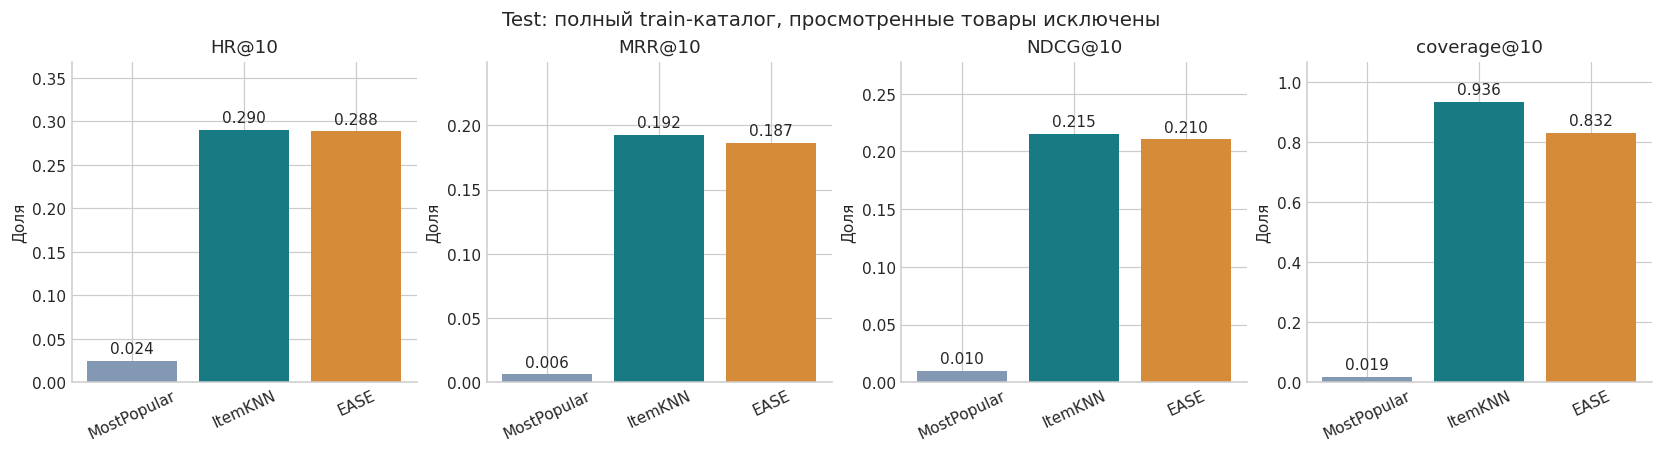

In [12]:
colors = ['#8298b3', '#187b83', '#d58b37']
fig, axes = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)
for ax, metric in zip(axes, metric_names):
    values = test_results[metric]
    bars = ax.bar(values.index, values.to_numpy(), color=colors)
    ax.bar_label(bars, labels=[f'{value:.3f}' for value in values], padding=3, fontsize=10)
    ax.set(title=metric, ylim=(0, min(1.07, values.max() * 1.22 + .015)))
    ax.tick_params(axis='x', rotation=25)
    ax.set_ylabel('Доля')
fig.suptitle('Test: полный train-каталог, просмотренные товары исключены', fontsize=13)
plt.show()

### Неопределённость сравнения

Для HR/MRR/NDCG рассчитываются 95%-е процентильные bootstrap-интервалы по пользователям
(2 000 повторов, фиксированный seed). Для сравнения с MostPopular используется **парный**
bootstrap: в каждом повторе у обеих моделей выбираются те же пользователи.
Отдельно тем же способом сравниваются ItemKNN и EASE. Интервал разности целиком выше нуля —
свидетельство улучшения на данном тестовом наборе.
Это не поправка на множественные сравнения и не гарантия качества на будущих данных:
интервалы условны относительно уже обученных моделей и имеющегося разбиения.
Coverage не является средним независимых вкладов пользователей, поэтому его не включаем
в эту таблицу интервалов.

In [13]:
n_bootstrap = 2000
n_test_users = len(test)
bootstrap_rng = np.random.default_rng(SEED)
bootstrap_indices = bootstrap_rng.integers(0, n_test_users,
                                           size=(n_bootstrap, n_test_users), dtype=np.int32)
interval_rows, difference_rows = [], []
for name, user_metrics in per_user_results.items():
    assert user_metrics.index.equals(per_user_results['MostPopular'].index)
    for metric in metric_names[:3]:
        values = user_metrics[metric].to_numpy()
        boot_means = values[bootstrap_indices].mean(axis=1)
        low, high = np.quantile(boot_means, [.025, .975])
        interval_rows.append({'Модель': name, 'Метрика': metric, 'Значение': values.mean(),
                              '95% low': low, '95% high': high})
        if name != 'MostPopular':
            delta = values - per_user_results['MostPopular'][metric].to_numpy()
            delta_boot = delta[bootstrap_indices].mean(axis=1)
            delta_low, delta_high = np.quantile(delta_boot, [.025, .975])
            difference_rows.append({'Модель − MostPopular': name, 'Метрика': metric,
                                    'Разность': delta.mean(), '95% low': delta_low,
                                    '95% high': delta_high})
confidence_intervals = pd.DataFrame(interval_rows)
paired_differences = pd.DataFrame(difference_rows)
display(confidence_intervals.set_index(['Модель', 'Метрика']))
display(paired_differences.set_index(['Модель − MostPopular', 'Метрика']))
personalized_rows = []
for metric in metric_names[:3]:
    delta = (per_user_results['ItemKNN'][metric] - per_user_results['EASE'][metric]).to_numpy()
    low, high = np.quantile(delta[bootstrap_indices].mean(axis=1), [.025, .975])
    personalized_rows.append({'Метрика': metric, 'ItemKNN − EASE': delta.mean(),
                              '95% low': low, '95% high': high})
personalized_comparison = pd.DataFrame(personalized_rows).set_index('Метрика')
display(personalized_comparison)
del bootstrap_indices

Значение  95% low  95% high
Модель      Метрика                             
MostPopular HR@10      0.0242   0.0170    0.0313
            MRR@10     0.0061   0.0036    0.0089
            NDCG@10    0.0101   0.0068    0.0136
ItemKNN     HR@10      0.2900   0.2691    0.3097
            MRR@10     0.1924   0.1763    0.2091
            NDCG@10    0.2155   0.1984    0.2325
EASE        HR@10      0.2883   0.2663    0.3081
            MRR@10     0.1865   0.1707    0.2026
            NDCG@10    0.2104   0.1941    0.2272

Разность  95% low  95% high
Модель − MostPopular Метрика                             
ItemKNN              HR@10      0.2658   0.2444    0.2872
                     MRR@10     0.1864   0.1702    0.2029
                     NDCG@10    0.2054   0.1884    0.2223
EASE                 HR@10      0.2641   0.2422    0.2856
                     MRR@10     0.1804   0.1648    0.1966
                     NDCG@10    0.2002   0.1833    0.2170

,ItemKNN − EASE,95% low,95% high
Метрика,,,
HR@10,0.0016,-0.0072,0.0104
MRR@10,0.0059,0.0015,0.0105
NDCG@10,0.0051,0.0007,0.0098


## 9. Диагностика качества

Срезы ниже объясняют результат, но не используются для перенастройки моделей.

- **Warm/cold:** какой вклад вносит отсутствие товара в train.
- **Рейтинг test ≥ 4:** качество на отложенных положительно оценённых взаимодействиях.
  Train при этом не фильтруется, поэтому это срез основной задачи, а не отдельный эксперимент
  с обучением только на положительных отзывах.
- **Длина истории:** меняется ли качество для более активных пользователей.
- **Совпадение дат:** отличается ли качество, когда цель приходится на тот же день, что
  последнее событие train. Это диагностический срез, а не глобальный временной эксперимент.

In [14]:
segment_rows = []
target_times = test.set_index('user_id').timestamp.reindex(train_context['users'])
last_train_times = train.groupby('user_id').timestamp.max().reindex(train_context['users'])
same_day_test = target_times.eq(last_train_times)
for name, users in per_user_results.items():
    masks = {
        'Все пользователи': np.ones(len(users), dtype=bool),
        'Warm target': users.warm_target,
        'Cold target': ~users.warm_target,
        'Рейтинг test ≥ 4': users.target_rating >= 4,
        'История train ≤ 4': users.history_length <= 4,
        'История train ≥ 5': users.history_length >= 5,
        'Цель в тот же день': same_day_test.to_numpy(),
        'Цель строго позднее по дате': (~same_day_test).to_numpy(),
    }
    for segment, mask in masks.items():
        subset = users.loc[mask]
        segment_rows.append({'Модель': name, 'Срез': segment, 'Пользователей': len(subset),
                             **subset[metric_names[:3]].mean().to_dict()})
segments = pd.DataFrame(segment_rows)
display(segments.set_index(['Срез', 'Модель']).sort_index())

cold_count = int((~per_user_results['MostPopular'].warm_target).sum())
cold_ceiling = 1 - cold_count / len(test)
display(Markdown(f'''
В test **{cold_count}** пользователей (**{cold_count / len(test):.2%}**) имеют товар,
которого нет в train-каталоге. Даже идеальный ранжировщик этого каталога не может превысить
**HR@10 = {cold_ceiling:.4f}** из-за одного только cold-start.
Основная таблица не исключает этих пользователей, поэтому не завышает качество таким отбором.
Warm-срез полезен для диагностики, но не заменяет основную оценку.
'''))

Пользователей  HR@10  MRR@10  NDCG@10
Срез                        Модель                                            
Cold target                 EASE                    28 0.0000  0.0000   0.0000
                            ItemKNN                 28 0.0000  0.0000   0.0000
                            MostPopular             28 0.0000  0.0000   0.0000
Warm target                 EASE                  1793 0.2928  0.1894   0.2137
                            ItemKNN               1793 0.2945  0.1955   0.2189
                            MostPopular           1793 0.0245  0.0062   0.0103
Все пользователи            EASE                  1821 0.2883  0.1865   0.2104
                            ItemKNN               1821 0.2900  0.1924   0.2155
                            MostPopular           1821 0.0242  0.0061   0.0101
История train ≤ 4           EASE                   944 0.4163  0.3045   0.3308
                            ItemKNN                944 0.4174  0.3094   0.3351
                            MostPopular            944 0.0275  0.0088   0.0130
История train ≥ 5           EASE                   877 0.1505  0.0595   0.0808
                            ItemKNN                877 0.1528  0.0666   0.0868
                            MostPopular            877 0.0205  0.0032   0.0071
Рейтинг test ≥ 4            EASE                  1334 0.3336  0.2302   0.2545
                            ItemKNN               1334 0.3351  0.2359   0.2595
                            MostPopular           1334 0.0172  0.0034   0.0065
Цель в тот же день          EASE                   490 0.6571  0.5306   0.5605
                            ItemKNN                490 0.6776  0.5565   0.5853
                            MostPopular            490 0.0143  0.0111   0.0119
Цель строго позднее по дате EASE                  1331 0.1525  0.0599   0.0815
                            ItemKNN               1331 0.1473  0.0584   0.0794
                            MostPopular           1331 0.0278  0.0042   0.0095


В test **28** пользователей (**1.54%**) имеют товар,
которого нет в train-каталоге. Даже идеальный ранжировщик этого каталога не может превысить
**HR@10 = 0.9846** из-за одного только cold-start.
Основная таблица не исключает этих пользователей, поэтому не завышает качество таким отбором.
Warm-срез полезен для диагностики, но не заменяет основную оценку.


### Пример персональных рекомендаций

Для воспроизводимого примера берётся первый пользователь в лексикографическом порядке,
без выбора по успешности предсказания. Отображаются ASIN, поскольку метаданные с названиями
товаров не входят в используемый файл. Рейтинг цели приводится только для интерпретации после
обучения и не участвует в расчёте рекомендаций.

In [15]:
example_user = train_context['users'][0]
example_index = train_context['user_to_idx'][example_user]
example_target = test.set_index('user_id').loc[example_user]
print('Пользователь:', example_user)
display(train.loc[train.user_id == example_user, ['item_id', 'rating', 'date']].reset_index(drop=True))
print(f'Отложенный товар: {example_target.item_id}; рейтинг: {example_target.rating:.0f}')
example_lists = pd.DataFrame({
    name: train_context['items'][recs[example_index]] for name, recs in recommendations.items()
}, index=pd.Index(range(1, K + 1), name='Позиция'))
display(example_lists.style.map(lambda value: 'background-color: #d6ede5'
                                if value == example_target.item_id else ''))
display(pd.DataFrame({name: result.loc[example_user, ['rank', 'HR@10', 'MRR@10', 'NDCG@10']]
                      for name, result in per_user_results.items()}).T)
print('rank = 0 означает отсутствие целевого товара в top-10.')

Пользователь: A100UD67AHFODS


,item_id,rating,date
0,B005S4Y65I,5.0000,2012-11-01 00:00:00+00:00
1,B009CCVMO0,5.0000,2013-01-07 00:00:00+00:00
2,B00F8K9KZS,5.0000,2014-03-08 00:00:00+00:00
3,B00BR082FW,5.0000,2014-07-23 00:00:00+00:00


Отложенный товар: B01617VQJ4; рейтинг: 4


,MostPopular,ItemKNN,EASE
Позиция,,,
1,B000050ZRE,B00MYXTCNC,B00MYXTCNC
2,B000EORV8Q,B01617VQJ4,B01617VQJ4
3,B0001FS9NE,B00E6LJBUO,B00E6LJBUO
4,B00EZPXYP4,B001GL8USQ,B001GL8USQ
5,B00F8K9MZQ,B01326J80Q,B01326J80Q
6,B008H3SW4I,B00FFIO0NA,B00F8K9L66
7,B00CTTEKJW,B00440D8PG,B01F7RJHIQ
8,B00EZQYC8G,B00F8K9L66,B00FFIO0NA
9,B005S4Y13K,B00M9GTL6M,B00H9A60O4


,rank,HR@10,MRR@10,NDCG@10
MostPopular,0,0.0000,0.0000,0.0000
ItemKNN,2,1.0000,0.5000,0.6309
EASE,2,1.0000,0.5000,0.6309


rank = 0 означает отсутствие целевого товара в top-10.


## 10. Выводы и ответы на вопросы проекта


In [16]:
baseline = test_results.loc['MostPopular']
test_leader = test_results['NDCG@10'].idxmax()
coverage_leader = test_results['coverage@10'].idxmax()
chosen = test_results.loc[selected_model]
delta_ndcg = chosen['NDCG@10'] - baseline['NDCG@10']
relative_gain = delta_ndcg / baseline['NDCG@10'] if baseline['NDCG@10'] else np.nan
model_lines = []
for name, row in test_results.iterrows():
    model_lines.append(
        f"- **{name}**: HR@10 = **{row['HR@10']:.4f}**, MRR@10 = **{row['MRR@10']:.4f}**, "
        f"NDCG@10 = **{row['NDCG@10']:.4f}**, coverage@10 = **{row['coverage@10']:.2%}** "
        f"({int(row['Рекомендовано товаров'])} из {len(train_context['items'])} товаров)."
    )

if selected_model != 'MostPopular':
    interval = paired_differences.loc[(paired_differences['Модель − MostPopular'] == selected_model)
                                       & (paired_differences['Метрика'] == 'NDCG@10')].iloc[0]
    uncertainty_text = (
        f"95%-й парный bootstrap-интервал разности NDCG@10 с baseline: "
        f"**[{interval['95% low']:.4f}; {interval['95% high']:.4f}]**. "
    )
    if interval['95% low'] > 0:
        uncertainty_text += 'Он целиком выше нуля: улучшение поддерживается этим тестовым набором.'
    elif interval['95% high'] < 0:
        uncertainty_text += 'Он целиком ниже нуля: выбранная модель уступает baseline на этом test.'
    else:
        uncertainty_text += 'Он включает ноль: уверенно утверждать улучшение над baseline нельзя.'
else:
    uncertainty_text = 'По validation усложнение относительно популярности не дало преимущества.'

leader_text = (f'Выбор по validation совпал с лидером test по NDCG@10: **{test_leader}**.'
               if test_leader == selected_model else
               f'На test максимальный NDCG@10 у **{test_leader}**, но основная модель **{selected_model}** '
               'была выбрана заранее по validation; результат test не используется для смены параметров.')

personalized_interval = personalized_comparison.loc['NDCG@10']
personalized_text = (
    f"Разность NDCG@10 между ItemKNN и EASE составляет "
    f"**{personalized_interval['ItemKNN − EASE']:+.4f}**; 95%-й парный интервал "
    f"**[{personalized_interval['95% low']:.4f}; {personalized_interval['95% high']:.4f}]**. "
)
if personalized_interval['95% low'] <= 0 <= personalized_interval['95% high']:
    personalized_text += ('Интервал включает ноль: наблюдаемого отрыва недостаточно, чтобы '
                          'уверенно утверждать превосходство ItemKNN над EASE.')
elif personalized_interval['95% low'] > 0:
    personalized_text += 'На данном наборе интервал поддерживает преимущество ItemKNN по NDCG@10.'
else:
    personalized_text += 'На данном наборе интервал поддерживает преимущество EASE по NDCG@10.'

strict_date_scores = segments.loc[(segments['Модель'] == selected_model)
                                  & (segments['Срез'] == 'Цель строго позднее по дате')].iloc[0]
tradeoff_text = (
    f'В данном эксперименте **{test_leader}** одновременно имеет максимальные точечные значения '
    'NDCG@10 и coverage: обязательного обмена одного качества на другое среди этих трёх моделей не наблюдается.'
    if test_leader == coverage_leader else
    f'Лидеры NDCG@10 (**{test_leader}**) и coverage (**{coverage_leader}**) различаются: '
    'выбор зависит от того, насколько важны точность и охват каталога.'
)

conclusions = f'''
### 1. Что показал анализ данных?

В исходном файле **{len(raw):,}** отзывов, **{raw.user_id.nunique():,}** пользователей
и **{raw.item_id.nunique():,}** товара. Удалено **{len(clean) - len(events)}** повторных пар,
сохранено первое взаимодействие. После очистки матрица разрежена на
**{1 - len(events)/(events.user_id.nunique()*events.item_id.nunique()):.2%}**;
медианная история содержит **{user_counts.median():.0f}** товаров.
Такая разреженность и неодинаковая популярность делают сравнение с простым baseline необходимым.

### 2. Как выполнено разбиение?

После исключения **{len(excluded_users)}** пользователей с историей короче трёх товаров
осталось **{len(test):,}** пользователей. У каждого последнее событие отложено в test:
**{len(train):,}** строк train и **{len(test):,}** строк test.
Внутри train сформированы **{len(fit):,}** строк fit и **{len(validation):,}** строк validation.
Проверены непересечение пар, одна цель на пользователя и порядок событий.

### 3. Какие модели построены и как оценены?

Построены **MostPopular**, **ItemKNN** и **EASE**. Параметры ItemKNN и EASE выбраны только
по validation NDCG@10. Затем модели переобучены на полном train.
Ранжируется весь train-каталог из **{len(train_context['items'])}** товаров без известных пользователю
позиций и без семплирования кандидатов. Основные метрики рассчитаны на всех **{len(test):,}** пользователях.

{chr(10).join(model_lines)}

### 4. Какую модель предпочесть по результатам эксперимента?

Заранее выбранная по validation модель — **{selected_model}**,
параметры: `{json.dumps(best_parameters[selected_model], ensure_ascii=False)}`.
Её HR@10 означает, что целевой товар попал в десятку у **{chosen['HR@10']:.2%}** пользователей.
Изменение NDCG@10 к MostPopular составляет **{delta_ndcg:+.4f}**
(**{relative_gain:+.2%}** относительно baseline).
{uncertainty_text}

{leader_text}

{personalized_text}

У **{int(same_day_test.sum())}** пользователей (**{same_day_test.mean():.2%}**) цель приходится на тот же
день, что последнее событие train. На остальных **{int(strict_date_scores['Пользователей'])}** пользователях
выбранная модель имеет HR@10 = **{strict_date_scores['HR@10']:.4f}** и
NDCG@10 = **{strict_date_scores['NDCG@10']:.4f}**.
**На срезе со строго более поздней датой качество заметно ниже общего.**
Это ограничивает интерпретацию общего HR@10 как качества будущей рекомендации:
нельзя установить реальный порядок событий внутри дня. Сам срез также не устраняет
временное смешение между разными пользователями и не заменяет нового временного эксперимента.

### 5. Есть ли компромисс между точностью и coverage?

Наибольший охват у **{coverage_leader}**: **{test_results.loc[coverage_leader, 'coverage@10']:.2%}** каталога.
У MostPopular охват **{baseline['coverage@10']:.2%}**, у выбранной модели — **{chosen['coverage@10']:.2%}**.
{tradeoff_text}
Популярность концентрирует выдачу на небольшой группе товаров; персонализация может расширять
её за счёт разных историй. Coverage показывает широту выдачи, но сам по себе не доказывает
релевантность, разнообразие внутри списка или полезность для покупателя.
Рекомендация модели относится только к этому offline-протоколу; итог для продукта требует
проверки на новых по времени данных и пользовательского эксперимента.
'''
display(Markdown(conclusions))


### 1. Что показал анализ данных?

В исходном файле **12,805** отзывов, **1,826** пользователей
и **802** товара. Удалено **921** повторных пар,
сохранено первое взаимодействие. После очистки матрица разрежена на
**99.19%**;
медианная история содержит **5** товаров.
Такая разреженность и неодинаковая популярность делают сравнение с простым baseline необходимым.

### 2. Как выполнено разбиение?

После исключения **5** пользователей с историей короче трёх товаров
осталось **1,821** пользователей. У каждого последнее событие отложено в test:
**10,056** строк train и **1,821** строк test.
Внутри train сформированы **8,235** строк fit и **1,821** строк validation.
Проверены непересечение пар, одна цель на пользователя и порядок событий.

### 3. Какие модели построены и как оценены?

Построены **MostPopular**, **ItemKNN** и **EASE**. Параметры ItemKNN и EASE выбраны только
по validation NDCG@10. Затем модели переобучены на полном train.
Ранжируется весь train-каталог из **796** товаров без известных пользователю
позиций и без семплирования кандидатов. Основные метрики рассчитаны на всех **1,821** пользователях.

- **MostPopular**: HR@10 = **0.0242**, MRR@10 = **0.0061**, NDCG@10 = **0.0101**, coverage@10 = **1.88%** (15 из 796 товаров).
- **ItemKNN**: HR@10 = **0.2900**, MRR@10 = **0.1924**, NDCG@10 = **0.2155**, coverage@10 = **93.59%** (745 из 796 товаров).
- **EASE**: HR@10 = **0.2883**, MRR@10 = **0.1865**, NDCG@10 = **0.2104**, coverage@10 = **83.17%** (662 из 796 товаров).

### 4. Какую модель предпочесть по результатам эксперимента?

Заранее выбранная по validation модель — **ItemKNN**,
параметры: `{"neighbors": 50, "shrinkage": 10.0}`.
Её HR@10 означает, что целевой товар попал в десятку у **29.00%** пользователей.
Изменение NDCG@10 к MostPopular составляет **+0.2054**
(**+2028.53%** относительно baseline).
95%-й парный bootstrap-интервал разности NDCG@10 с baseline: **[0.1884; 0.2223]**. Он целиком выше нуля: улучшение поддерживается этим тестовым набором.

Выбор по validation совпал с лидером test по NDCG@10: **ItemKNN**.

Разность NDCG@10 между ItemKNN и EASE составляет **+0.0051**; 95%-й парный интервал **[0.0007; 0.0098]**. На данном наборе интервал поддерживает преимущество ItemKNN по NDCG@10.

У **490** пользователей (**26.91%**) цель приходится на тот же
день, что последнее событие train. На остальных **1331** пользователях
выбранная модель имеет HR@10 = **0.1473** и
NDCG@10 = **0.0794**.
**На срезе со строго более поздней датой качество заметно ниже общего.**
Это ограничивает интерпретацию общего HR@10 как качества будущей рекомендации:
нельзя установить реальный порядок событий внутри дня. Сам срез также не устраняет
временное смешение между разными пользователями и не заменяет нового временного эксперимента.

### 5. Есть ли компромисс между точностью и coverage?

Наибольший охват у **ItemKNN**: **93.59%** каталога.
У MostPopular охват **1.88%**, у выбранной модели — **93.59%**.
В данном эксперименте **ItemKNN** одновременно имеет максимальные точечные значения NDCG@10 и coverage: обязательного обмена одного качества на другое среди этих трёх моделей не наблюдается.
Популярность концентрирует выдачу на небольшой группе товаров; персонализация может расширять
её за счёт разных историй. Coverage показывает широту выдачи, но сам по себе не доказывает
релевантность, разнообразие внутри списка или полезность для покупателя.
Рекомендация модели относится только к этому offline-протоколу; итог для продукта требует
проверки на новых по времени данных и пользовательского эксперимента.
